### Read SNOWPACK Output at Tram with HRRR-AK

created by Cassie Lumbrazo\
last updated: April 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/tram'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [3]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [18]:
ds_snowpack_hrrrak, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_tram_WY2025_base.smet")
ds_snowpack_met_hrrrak, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_tram_WY2025_base.smet")


/tmp/ipykernel_4157710/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_4157710/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


### Open Tram Observations

In [28]:
file = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  
ds_obs = xr.open_dataset(file)

# cut the datetime to be from 2024 10 01 to 2025 09 30 to match the snowpack output
ds_obs = ds_obs.sel(time=slice("2024-10-01T05:00:00", "2025-09-30T05:00:00"))

# convert temp to K for comparison with HRRR-AK data
# ds_obs['temp'] = ds_obs['temp'] + 273.15

ds_obs

<xarray.Dataset> Size: 559kB
Dimensions:           (time: 8728)
Coordinates:
  * time              (time) datetime64[ns] 70kB 2024-10-01T05:00:00 ... 2025...
Data variables:
    temp              (time) float64 70kB ...
    rh                (time) float64 70kB ...
    hs                (time) float64 70kB ...
    solar_rad         (time) float64 70kB ...
    precip_accum      (time) float64 70kB ...
    precip_rate       (time) float64 70kB ...
    precip_accum_1hr  (time) float64 70kB ...

In [39]:
# small cleaning of the hs data which looks awful (remove if I end up doing this somewhere else)
# remove ds_obs with hs > 150 cm 
# ds_obs = ds_obs.where(ds_obs['hs'] < 150, drop=True)

# try something else 
# remove all the ds_obs.hs values between 28 Feb and 02 March 2025 
ds_obs['hs'] = ds_obs['hs'].where(~((ds_obs['time'] >= np.datetime64("2025-02-20T00:00:00")) & (ds_obs['time'] <= np.datetime64("2025-03-04T23:59:59"))))

Text(0, 0.5, 'snow depth (cm)')

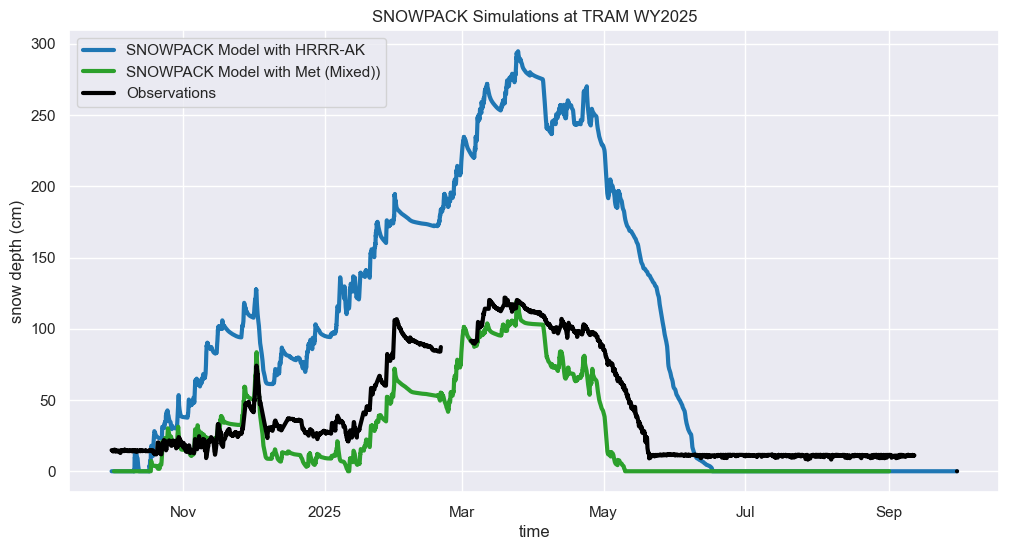

In [40]:
ds_snowpack_hrrrak.HS_mod.plot(label = 'SNOWPACK Model with HRRR-AK', linewidth = 3, color='tab:blue')
ds_snowpack_met_hrrrak.HS_mod.plot(label = 'SNOWPACK Model with Met (Mixed))', linewidth = 3, color='tab:green')
# ds_snowpack_met_hrrrak_ffill.HS_mod.plot(label = 'SNOWPACK Model with Met (Mixed) + Ffill', linewidth = 3, color='tab:red')
# ds_snowpack_met_hrrrak_scale.HS_mod.plot(label = 'SNOWPACK Model with Met (Mixed) + Ffill', linewidth = 3, color='tab:orange')
# 

ds_obs.hs.plot(label = 'Observations', linewidth = 3, color='black')


plt.title('SNOWPACK Simulations at TRAM WY2025')
plt.legend(loc = 'upper left')

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

Text(0, 0.5, 'SWE (mm)')

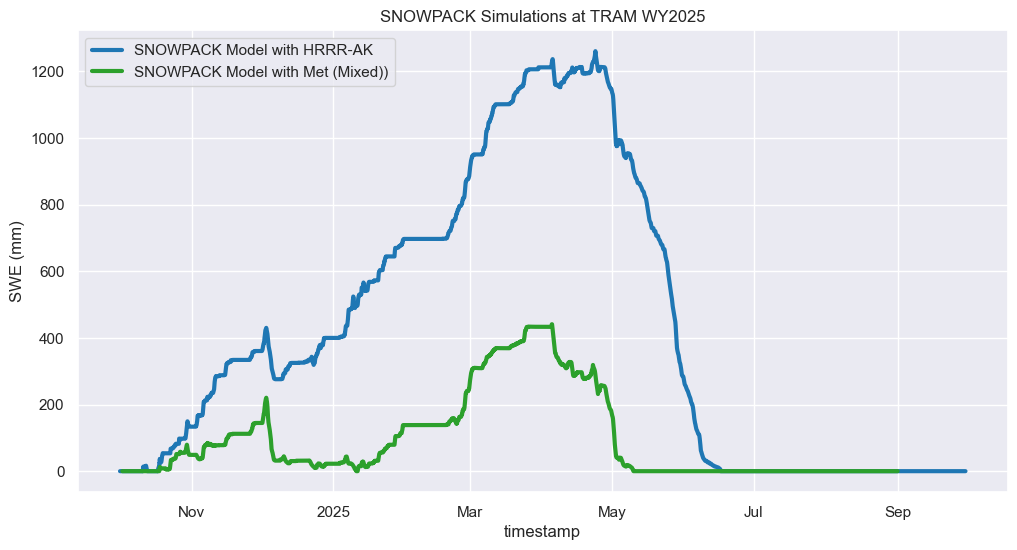

In [25]:
ds_snowpack_hrrrak.SWE.plot(label = 'SNOWPACK Model with HRRR-AK', linewidth = 3, color='tab:blue')
ds_snowpack_met_hrrrak.SWE.plot(label = 'SNOWPACK Model with Met (Mixed))', linewidth = 3, color='tab:green')
# ds_snowpack_met_hrrrak_ffill.SWE.plot(label = 'SNOWPACK Model with Met (Mixed) + Ffill', linewidth = 3, color='tab:red')
# ds_snowpack_met_hrrrak_scale.SWE.plot(label = 'SNOWPACK Mod?el with Met (Mixed) + Ffill', linewidth = 3, color='tab:orange')


plt.title('SNOWPACK Simulations at TRAM WY2025')
plt.legend(loc = 'upper left')

# plt.ylim([-10, 300])

plt.ylabel('SWE (mm)')